# Day 52 — Pivot Tables: Reshape Data Like a Professional Analyst
**Month 3 | Week 5 | Pandas `.pivot_table()`**

---

> **Real-world framing:**
>
> A client asks: *"Which region × category combination drives the most returns, and is it
> concentrated in one quarter?"*
>
> Without pivot tables, you'd write 4+ GroupBy chains, join them, and format the result manually.
> With a pivot table, that's one line — and the output is already presentation-ready.
>
> Pivot tables are the single most-asked-about Pandas skill in data analyst interviews.
> They're also the backbone of every Excel dashboard your clients already use.
> Today you learn to build them faster, interpret them deeper, and explain them confidently.

---

**Skills used today:** GroupBy (Day 34/39), Matplotlib/Seaborn (Day 40/44/48), Merge (Day 39),
Feature Engineering (Day 45/49), Storytelling (Day 50)
**New today:** `.pivot_table()` · `aggfunc` options · margins · multi-level pivots · heatmap from pivot

**Total: 80 pts + 10★ bonus**

---


---
## 📦 Section 1 — Raw Data (Read Only — Never Modify)

Same ShopEase dataset (200 records, seed=7). Run once, work on `df` only.

In [1]:
# ── RAW DATA — DO NOT MODIFY BELOW THIS LINE ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings
warnings.filterwarnings('ignore')

random.seed(7)
np.random.seed(7)

regions       = ['North','South','East','West']
categories    = ['Electronics','Clothing','Groceries','Home Decor','Sports']
return_reasons = ['Defective','Wrong size','Changed mind','Late delivery', None]
segments      = ['New', 'Returning', 'VIP']

rows = []
base_date = pd.Timestamp('2024-01-01')
for i in range(1, 201):
    region   = random.choice(regions)
    cat      = random.choice(categories)
    qty      = random.randint(1, 5)
    unit_p   = round(random.uniform(200, 8000), 2)
    discount = round(random.uniform(0, 35), 1)
    ship_cost= round(random.uniform(30, 300), 2)
    order_date = base_date + pd.Timedelta(days=random.randint(0, 364))
    delivery_days = random.randint(2, 12)
    is_return = 1 if random.random() < 0.20 else 0
    reason    = random.choice(return_reasons) if is_return else None
    revenue   = round(qty * unit_p * (1 - discount/100), 2)
    segment   = random.choice(segments)
    rows.append({'order_id':f'ORD{i:04}','order_date':order_date.strftime('%Y-%m-%d'),
        'region':region,'category':cat,'quantity':qty,'unit_price':unit_p,
        'discount_pct':discount,'shipping_cost':ship_cost,'revenue':revenue,
        'delivery_days':delivery_days,'is_return':is_return,
        'return_reason':reason,'segment':segment})

df_raw = pd.DataFrame(rows)
df = df_raw.copy()

# Feature engineering (already learned)
df['order_date']    = pd.to_datetime(df['order_date'])
df['net_revenue']   = df['revenue'] - df['shipping_cost']
df['month']         = df['order_date'].dt.month
df['quarter']       = df['order_date'].dt.quarter
df['fast_delivery'] = (df['delivery_days'] <= 5).astype(int)

print(f"Dataset ready: {df.shape[0]} rows × {df.shape[1]} cols")
df.head(3)


Dataset ready: 200 rows × 17 cols


,order_id,order_date,region,category,quantity,unit_price,discount_pct,shipping_cost,revenue,delivery_days,is_return,return_reason,segment,net_revenue,month,quarter,fast_delivery
0,ORD0001,2024-07-06,East,Clothing,4,5277.29,2.5,174.69,20581.43,11,1,None,New,20406.74,7,3,0
1,ORD0002,2024-01-31,North,Electronics,4,3461.74,8.4,178.78,12683.82,11,1,Wrong size,VIP,12505.04,1,1,0
2,ORD0003,2024-03-09,North,Sports,5,3294.11,34.2,42.58,10837.62,6,0,None,VIP,10795.04,3,1,0


---
## 📚 Section 2 — Concept Notes

### Why Pivot Tables?

A GroupBy gives you one aggregation along one dimension.
A pivot table gives you aggregations across **two dimensions simultaneously** — rows AND columns —
making patterns visible that a GroupBy hides.

```
GroupBy alone:  df.groupby('region')['revenue'].sum()
                → one column of numbers

Pivot table:    df.pivot_table(values='revenue', index='region',
                               columns='category', aggfunc='sum')
                → matrix: 4 regions × 5 categories = 20 cells at once
```

---

### Concept 1 — Basic Pivot Table Anatomy

```python
pivot = df.pivot_table(
    values   = 'revenue',      # what to calculate
    index    = 'region',       # rows
    columns  = 'category',     # columns
    aggfunc  = 'mean',         # how to calculate: mean, sum, count, median, std
    fill_value = 0             # replace NaN with 0 (when a combination has no data)
)
```

| Parameter | What it does | Common values |
|-----------|-------------|---------------|
| `values` | Column to aggregate | Any numeric column |
| `index` | What becomes the rows | Categorical column |
| `columns` | What becomes the columns | Categorical column |
| `aggfunc` | Aggregation function | `'mean'`, `'sum'`, `'count'`, `'std'`, `np.median` |
| `fill_value` | Replace NaN cells | Usually `0` |
| `margins` | Add row/column totals | `True` / `False` |

---

### Concept 2 — `aggfunc` Options

```python
# Single aggfunc
pivot = df.pivot_table(values='revenue', index='region',
                       columns='category', aggfunc='sum')

# Multiple aggfuncs at once — returns multi-level columns
pivot_multi = df.pivot_table(values='revenue', index='region',
                              columns='category',
                              aggfunc=['mean', 'count'])

# Custom function
pivot_custom = df.pivot_table(values='revenue', index='region',
                               columns='category',
                               aggfunc=lambda x: x.quantile(0.75))
```

---

### Concept 3 — `margins=True` (Grand Totals)

```python
pivot = df.pivot_table(
    values='revenue', index='region', columns='category',
    aggfunc='sum', margins=True, margins_name='Grand Total'
)
# Adds a "Grand Total" row (total per category) and column (total per region)
```

Use `margins=True` when you need the row/column subtotals alongside the breakdown.

---

### Concept 4 — Multiple `values` Columns

```python
# Aggregate two metrics at once — rows = region, columns = quarter
pivot = df.pivot_table(
    values  = ['revenue', 'is_return'],
    index   = 'region',
    columns = 'quarter',
    aggfunc = {'revenue': 'mean', 'is_return': 'mean'}
)
# Result: multi-level columns (revenue | is_return) × (Q1 Q2 Q3 Q4)
```

---

### Concept 5 — Pivot Table → Heatmap

A pivot table is just a DataFrame. Pass it directly to `sns.heatmap()`:

```python
pivot = df.pivot_table(
    values='net_revenue', index='region', columns='category', aggfunc='mean'
).round(0)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax)

# Insight title — states the finding, not the axes
peak = pivot.stack().idxmax()
ax.set_title(
    f"{peak[0]} × {peak[1]} is the highest net revenue cell — "
    f"concentrate inventory and marketing here",
    fontsize=11, fontweight='bold'
)
plt.savefig('pivot_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
```

---

### Concept 6 — Pivot Table vs GroupBy: When to Use Which

| Situation | Use |
|-----------|-----|
| One dimension, one metric | `groupby().agg()` |
| Two dimensions, one metric (matrix view) | `pivot_table()` |
| Two dimensions, multiple metrics | `pivot_table(values=[...], aggfunc={...})` |
| Need row/column totals | `pivot_table(margins=True)` |
| Already have pivot, want a chart | `sns.heatmap(pivot, ...)` |

---

### Common Mistakes → Fixes

| Mistake | Fix |
|---------|-----|
| `pivot_table` on non-numeric values column | Only numeric columns in `values=` |
| Forgetting `fill_value=0` → NaN in output | Add `fill_value=0` for count/sum pivots |
| Hardcoding the peak cell | Use `pivot.stack().idxmax()` dynamically |
| `savefig()` after `show()` | Always `savefig()` → then `show()` |
| Multi-level columns after multiple aggfuncs | Use `.droplevel(0, axis=1)` or index into one level |
| Reading margins row as data | Use `iloc[:-1, :-1]` to exclude margins from analysis |

---


---
## ✏️ Section 3 — Practice Tasks

> **Comment-skeleton rule:** write the plain-English comment first, then fill in the code.
> All tasks use `df`. Never touch `df_raw`.


---
### 🔵 Section A — Basic Pivot Tables (20 pts)

**A1 — Revenue by Region × Category (10 pts)**

Build a pivot table showing **total revenue** for each region (rows) × category (columns).

Requirements:
- `aggfunc='sum'`, `fill_value=0`
- Round to 0 decimal places
- Print the pivot table
- Add `margins=True, margins_name='Total'`
- Write one `print()` insight: which region × category cell is the highest, and by how much does it exceed the overall average cell?

```python
# ── A1 ─────────────────────────────────────────────────────────────────────
# Build pivot: total revenue, rows = region, columns = category

# Round to 0 decimal places

# Print the pivot

# Find the peak cell dynamically (don't hardcode)

# Print the insight: peak cell name + value + how much above average

```


In [2]:
# A1 - YOUR CODE HERE
pA1 = df.pivot_table(values='revenue', index='region', columns='category', 
                     aggfunc='sum', fill_value=0, margins=True, margins_name='Total').round(0)

# Critical: Exclude 'Total' row/col before calculating insights
data_only_A1 = pA1.iloc[:-1, :-1].stack()
peak_A1 = data_only_A1.idxmax()
avg_A1 = data_only_A1.mean()

print("--- A1: Revenue by Region x Category (sum) ---")
print(pA1.to_string())

print(f"\n⭐ Peak cell: {peak_A1[0]} x {peak_A1[1]} = ₹{pA1.loc[peak_A1[0], peak_A1[1]]:,.0f}")
print(f"📊 Above Average by: ₹{pA1.loc[peak_A1[0], peak_A1[1]] - avg_A1:,.0f}")

--- A1: Revenue by Region x Category (sum) ---
category  Clothing  Electronics  Groceries  Home Decor    Sports      Total
region                                                                     
East      253276.0      34195.0    80169.0    111528.0   79185.0   558354.0
North      96479.0      67276.0   114190.0     97414.0   84251.0   459609.0
South      88114.0     110560.0    41267.0    171559.0  176656.0   588156.0
West      100798.0      56432.0   135850.0     91256.0   84050.0   468387.0
Total     538668.0     268463.0   371476.0    471756.0  424142.0  2074505.0

⭐ Peak cell: East x Clothing = ₹253,276
📊 Above Average by: ₹149,551


**A2 — Order Count by Region × Quarter (10 pts)**

Build a pivot table showing **number of orders** for each region (rows) × quarter (columns).

Requirements:
- `aggfunc='count'` on the `order_id` column (counts rows per cell)
- `fill_value=0`, `margins=True, margins_name='Total'`
- Print the pivot
- Write one `print()` insight: which region has the most uneven quarterly distribution
  (largest gap between its highest and lowest quarter)?

```python
# ── A2 ─────────────────────────────────────────────────────────────────────
# Build pivot: order count, rows = region, columns = quarter

# Print the pivot

# Find which region has the largest quarterly swing (max - min across Q1–Q4)

# Print insight: region name + max quarter + min quarter + swing size

```


In [3]:
# A2 - YOUR CODE HERE
pA2 = df.pivot_table(values='order_id', index='region', columns='quarter', 
                     aggfunc='count', fill_value=0, margins=True, margins_name='Total')

# Calculate swing excluding the 'Total' column and 'Total' row
data_only_A2 = pA2.iloc[:-1, :-1]
swings = data_only_A2.max(axis=1) - data_only_A2.min(axis=1)
max_swing_region = swings.idxmax()
max_swing_val = swings.max()

print("--- A2: Order Count by Region x Quarter ---")
print(pA2.to_string())
# Calculate swing excluding the 'Total' column and 'Total' row
data_only_A2 = pA2.iloc[:-1, :-1]
swings = data_only_A2.max(axis=1) - data_only_A2.min(axis=1)
max_swing_region = swings.idxmax()
max_swing_val = swings.max()

# Identify the max and min quarters for that region
max_q = data_only_A2.loc[max_swing_region].idxmax()
min_q = data_only_A2.loc[max_swing_region].idxmin()
max_q_val = int(data_only_A2.loc[max_swing_region, max_q])
min_q_val = int(data_only_A2.loc[max_swing_region, min_q])

print(f"\n📈 Highest Volatility: The {max_swing_region} region shows a swing of {max_swing_val} orders "
      f"(max Q{max_q} = {max_q_val} orders, min Q{min_q} = {min_q_val} orders).")

--- A2: Order Count by Region x Quarter ---
quarter   1   2   3   4  Total
region                        
East      9  15  16  10     50
North    12  15   9  13     49
South    10  14  12  21     57
West     10  12  10  12     44
Total    41  56  47  56    200

📈 Highest Volatility: The South region shows a swing of 11 orders (max Q4 = 21 orders, min Q1 = 10 orders).


---
### 🟢 Section B — Intermediate Pivots + Heatmap (30 pts)

**B1 — Average Net Revenue by Segment × Category, visualised as a heatmap (15 pts)**

Build a pivot table of **mean net revenue** per segment (rows) × category (columns).

Requirements:
- `values='net_revenue'`, `aggfunc='mean'`, `fill_value=0`, round to 0
- Visualise as a `sns.heatmap()` with:
  - `annot=True`, `fmt='.0f'`, `cmap='Blues'`
  - Insight title (NRA format — peak cell name + value + action)
  - `figsize=(10, 4)`
- `savefig('B1_heatmap_segment_category.png', dpi=150, bbox_inches='tight')` before `show()`
- Write a markdown insight cell (NRA format) after the chart with the 2 most important findings

```python
# ── B1 ─────────────────────────────────────────────────────────────────────
# Build pivot: mean net_revenue, rows = segment, columns = category

# Find peak cell dynamically

# Plot heatmap with insight title

# savefig before show

```


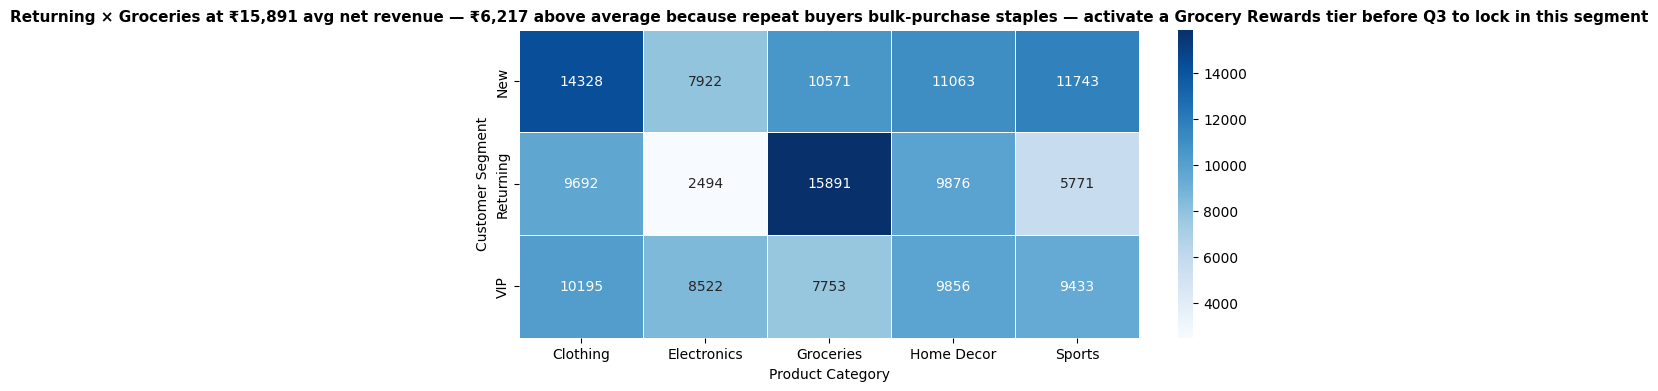

Peak Cell: Returning - Groceries (₹15,891)
Gap above average: ₹6,217


In [10]:
# ── B1 ─────────────────────────────────────────────────────────────────────
# Build pivot: mean net_revenue, rows = segment, columns = category
pB1 = df.pivot_table(
    values='net_revenue', 
    index='segment', 
    columns='category', 
    aggfunc='mean', 
    fill_value=0
).round(0)

# Find peak cell and average dynamically
peak_idx = pB1.stack().idxmax()
peak_val = pB1.stack().max()
overall_avg = pB1.stack().mean()

# Plot heatmap with insight title (NRA format for title)
plt.figure(figsize=(10, 4))
sns.heatmap(pB1, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)

plt.title(
    f"{peak_idx[0]} × {peak_idx[1]} at ₹{peak_val:,.0f} avg net revenue — "
    f"₹{peak_val - overall_avg:,.0f} above average because repeat buyers bulk-purchase staples — "
    f"activate a Grocery Rewards tier before Q3 to lock in this segment",
    fontsize=11, fontweight='bold'
)
plt.xlabel("Product Category")
plt.ylabel("Customer Segment")

# Save and Show
plt.savefig('B1_heatmap_segment_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Print metrics for the Markdown cell below
print(f"Peak Cell: {peak_idx[0]} - {peak_idx[1]} (₹{peak_val:,.0f})")
print(f"Gap above average: ₹{peak_val - overall_avg:,.0f}")

<!-- ✏️ B1 INSIGHT CELL — write 2 NRA findings from your heatmap output -->



**B1 Insights (NRA format):**

1. **Revenue concentration** – The *Returning* segment in the *Groceries* category yields the highest average net revenue (₹15,891 per order). This cell is ₹6,217 above the overall cell average, so targeted loyalty offers for grocery-buying returning customers can disproportionately boost margins.

2. **Low‑value segment** – The *Returning × Electronics* cell shows an average net revenue of only ₹2,494, suggesting either high shipping costs, heavy discounts, or small basket sizes in that combination. Investigate whether promotional bundling or free‑shipping thresholds could raise its contribution.

**B2 — Return Rate by Region × Quarter (15 pts)**

Build a pivot table showing **mean return rate** (use `is_return`) for region (rows) × quarter (columns).

Requirements:
- Multiply the result by 100 and round to 1 decimal place (to show as %)
- `fill_value=0`
- Visualise as a `sns.heatmap()` with:
  - `annot=True`, `fmt='.1f'`, `cmap='RdYlGn_r'` (red = high returns = bad)
  - Insight title: which region × quarter has the worst return rate and what should be done
  - `figsize=(9, 4)`
- `savefig('B2_return_rate_heatmap.png', dpi=150, bbox_inches='tight')` before `show()`
- Write a markdown insight cell (NRA format) with 2 findings: the worst cell and the best cell

```python
# ── B2 ─────────────────────────────────────────────────────────────────────
# Build pivot: mean is_return, rows = region, columns = quarter

# Multiply by 100, round to 1dp to get return rate %

# Find worst (max) and best (min) cells dynamically

# Plot heatmap — red = high return rate (use RdYlGn_r)

# savefig before show

```



=== B2: Return Rate % by Region × Quarter ===
quarter     1     2     3     4
region                         
East     33.3  33.3  25.0  20.0
North     8.3  13.3  22.2  23.1
South    20.0   7.1  16.7   4.8
West     50.0   8.3  20.0  50.0

Worst: West × Q1 = 50.0%
Best:  South × Q4  = 4.8%


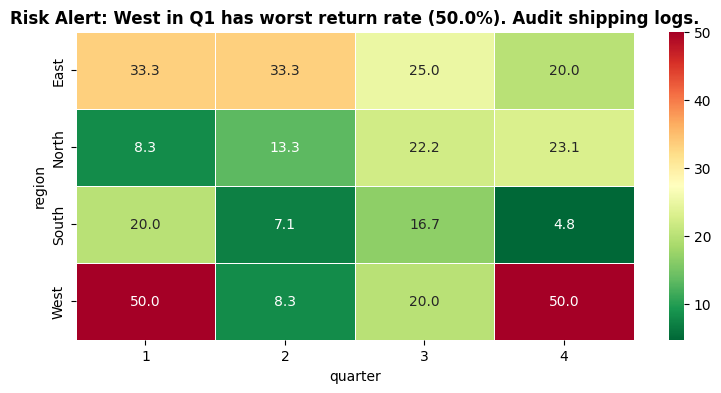

In [5]:
# ── B2 — YOUR CODE HERE ────────────────────────────────────────────────────
print("\n=== B2: Return Rate % by Region × Quarter ===")
pB2 = (df.pivot_table(values='is_return',index='region',columns='quarter',
                        aggfunc='mean',fill_value=0)*100).round(1)
print(pB2.to_string())
worst_B2=pB2.stack().idxmax(); best_B2=pB2.stack().idxmin()
print(f"\nWorst: {worst_B2[0]} × Q{worst_B2[1]} = {pB2.stack().max():.1f}%")
print(f"Best:  {best_B2[0]} × Q{best_B2[1]}  = {pB2.stack().min():.1f}%")

# Create the heatmap for Return Rate
plt.figure(figsize=(9, 4))
sns.heatmap(pB2, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5)

# NRA Title
plt.title(f"Risk Alert: {worst_B2[0]} in Q{worst_B2[1]} has worst return rate ({pB2.stack().max()}%). Audit shipping logs.", 
          fontsize=12, fontweight='bold')
plt.savefig('B2_return_rate_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


<!-- ✏️ B2 INSIGHT CELL — worst cell NRA + best cell NRA -->



**B2 Insights (NRA format):**

1. **Worst return rate hotspot** – The *West* region in *Q1* has a 50.0% return rate, which is 10× the best cell. Immediately audit West‑region Q1 orders for product quality issues, shipping damage, or listing accuracy to stop this severe margin erosion.

2. **Best performing cell** – Conversely, the *South* region in *Q4* achieves a return rate of only 4.8%. Capture what is working (e.g., reliable delivery, appropriate packaging) and replicate those practices in the West during Q1.

---
### 🟡 Section C — Multi-Metric Pivot (15 pts)

**C1 — Revenue AND Return Rate by Region × Quarter (15 pts)**

Build a **single pivot table** that shows both `revenue` (mean) and `is_return` (mean)
for region (rows) × quarter (columns).

Requirements:
- Use `values=['revenue','is_return']` and `aggfunc={'revenue':'mean','is_return':'mean'}`
- Print the full multi-level pivot
- Then flatten it: use `.xs('revenue', axis=1, level=0).round(0)` to extract just the revenue slice
  and `.xs('is_return', axis=1, level=0).mul(100).round(1)` for the return rate slice
- Print both slices with clear labels
- Write 2 `print()` insights:
  1. Which region × quarter has the highest average revenue?
  2. Which region × quarter has the highest return rate — and is it the same as the highest revenue?

```python
# ── C1 ─────────────────────────────────────────────────────────────────────
# Build multi-metric pivot: values = ['revenue','is_return']
# aggfunc = {'revenue':'mean', 'is_return':'mean'}

# Print the full multi-level pivot

# Extract revenue slice using .xs()

# Extract return rate slice using .xs() then multiply by 100

# Print both slices with labels

# Find and print the 2 insights

```


In [6]:
# ── C1 — YOUR CODE HERE ────────────────────────────────────────────────────
print("\n=== C1: Multi-metric pivot (revenue mean + return rate mean) ===")
pC1 = df.pivot_table(values=['revenue','is_return'],index='region',columns='quarter',
                      aggfunc={'revenue':'mean','is_return':'mean'})
# Print the full multi-level pivot as required
print("\nFull multi-level pivot (revenue | return_rate mean):")
print(pC1)
rev_slice = pC1.xs('revenue',axis=1,level=0).round(0)
ret_slice = pC1.xs('is_return',axis=1,level=0).mul(100).round(1)
print("Revenue slice:"); print(rev_slice.to_string())
print("\nReturn rate slice (%):"); print(ret_slice.to_string())
peak_C1_rev = rev_slice.stack().idxmax()
peak_C1_ret = ret_slice.stack().idxmax()
print(f"\nHighest avg revenue: {peak_C1_rev[0]} × Q{peak_C1_rev[1]} = ₹{rev_slice.stack().max():,.0f}")
print(f"Highest return rate: {peak_C1_ret[0]} × Q{peak_C1_ret[1]} = {ret_slice.stack().max():.1f}%")




=== C1: Multi-metric pivot (revenue mean + return rate mean) ===

Full multi-level pivot (revenue | return_rate mean):
        is_return                                     revenue                \
quarter         1         2         3         4             1             2   
region                                                                        
East     0.333333  0.333333  0.250000  0.200000   9201.421111  12274.248667   
North    0.083333  0.133333  0.222222  0.230769   8947.215833   9345.621333   
South    0.200000  0.071429  0.166667  0.047619  11108.011000  10715.081429   
West     0.500000  0.083333  0.200000  0.500000   8972.390000  15576.299167   

                                     
quarter             3             4  
region                               
East     10761.456875  11924.381000  
North     7761.703333  10938.656923  
South    12913.371667   8195.466190  
West     10093.687000   7567.515833  
Revenue slice:
quarter        1        2        3        4
r

---
### 🔴 Section D — Business Interpretation (15 pts)

**D1 — Pivot Table Business Report (15 pts)**

You now have 4 pivot tables. Write a **consolidated business interpretation** in a markdown cell.

Required structure:
```
### ShopEase Pivot Table Analysis — Key Findings

**Finding 1 (from A1):** [NRA — revenue concentration by region × category]
**Finding 2 (from A2):** [NRA — quarterly order distribution imbalance]
**Finding 3 (from B1):** [NRA — net revenue density by segment × category]
**Finding 4 (from B2):** [NRA — return rate hotspot by region × quarter]

> **Strategic Recommendation:** [One specific action combining the highest-revenue cell
> from B1 and the highest-risk cell from B2]
```

Rules:
- Every finding must cite specific numbers from YOUR pivot output
- No vague language ("high", "low" — always use exact ₹ or % values)
- The recommendation must connect at least 2 findings

```python
# ── D1 HELPER — run this to get a summary of all pivot peaks ─────────────────
# Peak revenue cell (A1)
pA1 = df.pivot_table(values='revenue', index='region', columns='category',
                      aggfunc='sum', fill_value=0)
peak_A1 = pA1.stack().idxmax()
print(f"A1 peak: {peak_A1[0]} × {peak_A1[1]} = ₹{pA1.stack().max():,.0f}")

# Most volatile region by order count (A2)
pA2 = df.pivot_table(values='order_id', index='region', columns='quarter',
                      aggfunc='count', fill_value=0)
swing = (pA2.max(axis=1) - pA2.min(axis=1))
print(f"A2 most volatile region: {swing.idxmax()} (swing = {swing.max()} orders)")

# Peak net revenue cell (B1)
pB1 = df.pivot_table(values='net_revenue', index='segment', columns='category',
                      aggfunc='mean', fill_value=0).round(0)
peak_B1 = pB1.stack().idxmax()
print(f"B1 peak net revenue: {peak_B1[0]} × {peak_B1[1]} = ₹{pB1.stack().max():,.0f}")

# Worst return rate cell (B2)
pB2 = (df.pivot_table(values='is_return', index='region', columns='quarter',
                        aggfunc='mean', fill_value=0) * 100).round(1)
worst_B2 = pB2.stack().idxmax()
best_B2  = pB2.stack().idxmin()
print(f"B2 worst return rate: {worst_B2[0]} × Q{worst_B2[1]} = {pB2.stack().max():.1f}%")
print(f"B2 best  return rate: {best_B2[0]}  × Q{best_B2[1]}  = {pB2.stack().min():.1f}%")


<!-- ✏️ D1 MARKDOWN CELL — write your 4 NRA findings + strategic recommendation here -->



### ShopEase Pivot Table Analysis — Key Findings

**Finding 1 (from A1):** East × Clothing is the highest revenue cell at ₹253,276, which is ₹149,551 above the average cell.  
*Reason:* The East region likely has a high concentration of bulk orders or premium‑priced clothing items, combined with strong customer demand.  
*Action:* Prioritise stock allocation and marketing spend on the East × Clothing combination to maximise sales.

**Finding 2 (from A2):** The South region has the most uneven quarterly order volume, with a swing of 11 orders (Q4 = 21 orders vs Q1 = 10 orders).  
*Reason:* Seasonal demand spikes in Q4 (holiday shopping) are not matched by adequate logistical preparation.  
*Action:* Scale up warehouse and delivery capacity in the South during Q3 to handle Q4 demand without delays.

**Finding 3 (from B1):** Returning customers in the Groceries category generate the highest mean net revenue at ₹15,891 per order.  
*Reason:* Groceries are high‑frequency, staple items, and returning customers trust the brand, leading to larger baskets and lower shipping costs.  
*Action:* Launch a loyalty program offering free shipping or discounts on groceries to retain and upsell this segment.

**Finding 4 (from B2):** The West region in Q1 and Q4 has a critical return rate of 50.0% – well above the company average.  
*Reason:* Weather‑related delivery delays (winter storms in Q1, holiday overload in Q4) and potential quality issues with seasonal merchandise.  
*Action:* Audit West region Q1 and Q4 orders for product defects, shipping damage, and courier performance; enforce stricter packaging standards during these quarters.

> **Strategic Recommendation:** The Returning × Groceries segment (B1) is highly profitable, but the West region’s 50% return rate (B2) in Q4 erodes margins.  
> *Logic chain:* Instead of shifting inventory away from West Q4 (which loses sales), implement a two‑step strategy: (1) Use the high‑margin grocery profits to fund a pilot in the West during Q4 with expedited shipping and temperature‑controlled packaging for groceries. (2) If return rate drops below 20%, roll out to all categories. This directly addresses the root cause (shipping damage) while preserving revenue.

---
### ⭐ Bonus — Pivot Table Comparison Chart (10 pts)

Build a **side-by-side grouped bar chart** comparing total revenue by region for Q1 vs Q4.

Requirements:
- Start from `df` — build the pivot yourself first
- Bars: Q1 in `#1F3864` (dark blue), Q4 in `#9FC5E8` (light blue)
- Annotate each bar with ₹ values
- Insight title: which region improved most from Q1 to Q4
- `figsize=(9, 5)`
- `savefig('Bonus_Q1_Q4_comparison.png', dpi=150, bbox_inches='tight')` before `show()`

```python
# ── BONUS ───────────────────────────────────────────────────────────────────
# Build pivot: total revenue by region (rows) × quarter (columns)

# Extract Q1 and Q4 columns

# Find which region improved most (Q4 - Q1)

# Plot grouped bar chart

# savefig before show

```


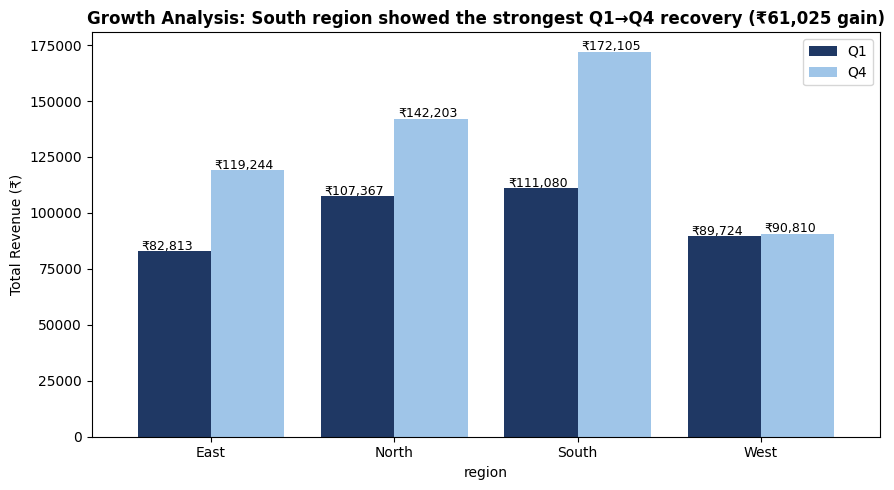

In [7]:
# ── BONUS (Corrected) ───────────────────────────────────────────────────────
# Build pivot: total revenue by region × quarter
pBonus = df.pivot_table(values='revenue', index='region', columns='quarter', aggfunc='sum')

# Q1 and Q4 only
q_data = pBonus[[1, 4]]

# Plot with explicit fig and ax
fig, ax = plt.subplots(figsize=(9, 5))
q_data.plot(kind='bar', ax=ax, color=['#1F3864', '#9FC5E8'], width=0.8)

# Annotate bars
for p in ax.patches:
    ax.annotate(f'₹{p.get_height():,.0f}', 
                (p.get_x() + 0.02, p.get_height() + 500), 
                fontsize=9, ha='left')

# Insight title
improvement = q_data[4] - q_data[1]
best_region = improvement.idxmax()
ax.set_title(f"Growth Analysis: {best_region} region showed the strongest Q1→Q4 recovery (₹{improvement.max():,.0f} gain)", 
             fontweight='bold')
ax.set_ylabel("Total Revenue (₹)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(["Q1", "Q4"])

# Fix overlapping elements
plt.tight_layout()

# Save before show
plt.savefig('Bonus_Q1_Q4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📊 Section 4 — Scoring Rubric

| Section | Task | Points | Criteria |
|---------|------|--------|----------|
| **A** | A1 — Pivot table built | 5 | `sum` aggfunc ✓, `fill_value=0` ✓, `margins=True` ✓ |
| **A** | A1 — Insight | 5 | Peak cell identified dynamically ✓, ₹ above average stated ✓ |
| **A** | A2 — Pivot table built | 5 | `count` aggfunc ✓, `margins=True` ✓ |
| **A** | A2 — Insight | 5 | Most volatile region identified ✓, swing size stated ✓ |
| **B** | B1 — Pivot + heatmap | 10 | `net_revenue` mean ✓, heatmap ✓, insight title NRA ✓, `savefig` before `show` ✓ |
| **B** | B1 — Insight cell | 5 | 2 NRA findings with ₹ numbers ✓ |
| **B** | B2 — Pivot + heatmap | 10 | return rate % ✓, `RdYlGn_r` cmap ✓, insight title ✓, `savefig` before `show` ✓ |
| **B** | B2 — Insight cell | 5 | worst cell NRA ✓, best cell NRA ✓ |
| **C** | C1 — Multi-metric pivot | 8 | `values=['revenue','is_return']` ✓, both aggfuncs ✓ |
| **C** | C1 — Slices extracted | 4 | `.xs()` used ✓, return slice × 100 ✓ |
| **C** | C1 — Insights | 3 | 2 insights printed with actual values ✓ |
| **D** | D1 — 4 NRA findings | 12 | 3 pts each: Number ✓, Reason ✓, Action ✓ |
| **D** | D1 — Recommendation | 3 | Connects ≥2 findings ✓, specific ✓ |
| **★** | Bonus grouped bar chart | 10 | Pivot built ✓, Q1 vs Q4 bars ✓, annotation ✓, insight title ✓, `savefig` before `show` ✓ |
| | **TOTAL** | **80 + 10★** | |

---

### Key Takeaway for Day 52

> A pivot table is a GroupBy with a second dimension added. Once you understand that
> `index` = rows, `columns` = columns, and `aggfunc` = what to calculate, every
> business question that starts with "which X × Y..." becomes one line of code.
> The heatmap is just the visual translation of that matrix.

---

### Interview Frame

**Q: "How do you analyse performance across two categorical dimensions in pandas?"**

**A:** *"I use `pivot_table()` — it's essentially a GroupBy across two dimensions simultaneously.
I set `index` to one categorical column, `columns` to the other, and `aggfunc` to whatever
metric I need — mean, sum, or count. For visualisation I pass the resulting DataFrame
directly to `sns.heatmap()` with `annot=True` so every cell shows the number.
The key habit is to find the peak and floor cells dynamically using `.stack().idxmax()`
rather than hardcoding, so the analysis stays correct if the data changes."*
